# 노트북 2 — 피험자 선별 관문 (CSP+LDA)

**EEG Resonate Encoding SNN 프로젝트** · 노트북 2

이 노트북의 65% 기준은 프로젝트 전체의 통과/미달을 기록하는 게 아니라, **피험자를 선별하는 관문**이다.
mu 대역(8–13 Hz)으로 대역통과한 뒤 CSP(학습셋에서만 적합)+LDA로 피험자별 5-fold CV 정확도를 구하고,
65% 이상인 피험자만 다음 단계로 넘긴다. 노트북 1이 만든 두 창 길이(0.5–2.0s, 0.5–3.5s) 중 통과 인원이 더 많은
쪽을 선택해 `selected_subjects.json`으로 저장한다.

### 학습 목표
- mu 대역만 남기는 대역통과 필터를 적용한다.
- CSP(학습셋에서만 적합)+LDA 파이프라인으로 피험자별 5-fold CV 정확도를 재다.
- 두 창 길이의 통과 인원수·평균 정확도를 비교해 어느 쪽을 쓸지 결정한다.
- 최종 통과 피험자 목록을 `selected_subjects.json`으로 저장한다.


## 1. 설치와 임포트

In [1]:
%pip install -q scikit-learn mne

import json
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt
import koreanize_matplotlib          # 그래프 한글 폰트

np.random.seed(0)                    # 재현성


Note: you may need to restart the kernel to use updated packages.


## 2. 파라미터 설정

노트북 1이 저장한 두 창 길이 파일을 모두 불러온다.

In [2]:
MU_BAND = (8.0, 13.0)         # CSP에 쓸 mu 대역 [Hz]
N_SPLITS = 5                  # 5-fold 교차검증
N_CSP_COMPONENTS = 6          # CSP 성분 수 (9채널 중 6개)
PASS_THRESHOLD = 0.65         # 선별 통과 기준

WINDOW_FILES = {
    'short': {'label': '0.5-2.0s', 'path': '../data/processed/eeg_epochs.npz', 'num_steps': 192},
    'long':  {'label': '0.5-3.5s', 'path': '../data/processed/eeg_epochs_long.npz', 'num_steps': 384},
}
OUT_JSON_PATH = '../data/processed/selected_subjects.json'


## 3. mu 대역통과 필터

CSP는 특정 대역에서 가장 잘 작동하므로, 이미 1–45 Hz로 대역통과된 신호에 mu(8–13 Hz) 대역통과 필터를 한 번 더 거친다.

In [3]:
def bandpass_filter(X, fs, band, order=4):
    # X: (시행,채널,시간)
    nyq = fs / 2
    b, a = butter(order, [band[0] / nyq, band[1] / nyq], btype='band')
    return filtfilt(b, a, X, axis=2)


## 4. 피험자별 CSP+LDA 5-fold CV 정확도

`Pipeline(CSP, LDA)`를 `cross_val_score`에 넣으면 각 fold마다 **학습 부분에서만 CSP가 적합**되고 검증 부분에는 적용만 된다(자동 방지).

In [4]:
def csp_lda_accuracy(X_mu_subj, y_subj, n_splits=N_SPLITS, seed=0):
    csp = CSP(n_components=N_CSP_COMPONENTS, reg=None, log=True, norm_trace=False)
    lda = LinearDiscriminantAnalysis()
    clf = Pipeline([('csp', csp), ('lda', lda)])
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    scores = cross_val_score(clf, X_mu_subj, y_subj, cv=cv)
    return scores.mean()


## 5. 두 창 길이 전체에 선별 관문 적용

In [5]:
gate_rows = []

for window_key, cfg in WINDOW_FILES.items():
    npz = np.load(cfg['path'])
    X, y, subject_ids, fs = npz['X'], npz['y'], npz['subject_ids'], int(npz['fs'])
    X_mu = bandpass_filter(X, fs, MU_BAND)

    for subject_id in sorted(set(subject_ids.tolist())):
        mask = subject_ids == subject_id
        acc = csp_lda_accuracy(X_mu[mask], y[mask])
        gate_rows.append({
            'window': window_key,
            'window_label': cfg['label'],
            'subject_id': subject_id,
            'csp_lda_acc': acc,
        })
        print(f"[{cfg['label']}] S{subject_id:02d}: {acc*100:5.1f}%")

gate_df = pd.DataFrame(gate_rows)
gate_df['passed'] = gate_df['csp_lda_acc'] >= PASS_THRESHOLD   # 불리언 비교 (if 없이)


Computing rank from data with rank=None


    Using tolerance 0.093 (2.2e-16 eps * 9 dim * 4.7e+13  max singular value)


    Estimated rank (data): 9


    data: rank 9 computed from 9 data channels with 0 projectors


Reducing data rank from 9 -> 9


...

Estimating class=0 covariance using EMPIRICAL


Done.


Estimating class=1 covariance using EMPIRICAL


Done.


[0.5-3.5s] S40:  51.1%


## 6. 창 길이별 비교 — 통과 인원·평균 정확도

  window_label  n_passed  n_total  mean_acc_pct  std_acc_pct
0     0.5-3.5s        10       40     58.555556    17.979975
1     0.5-2.0s         7       40     56.944444    15.327490

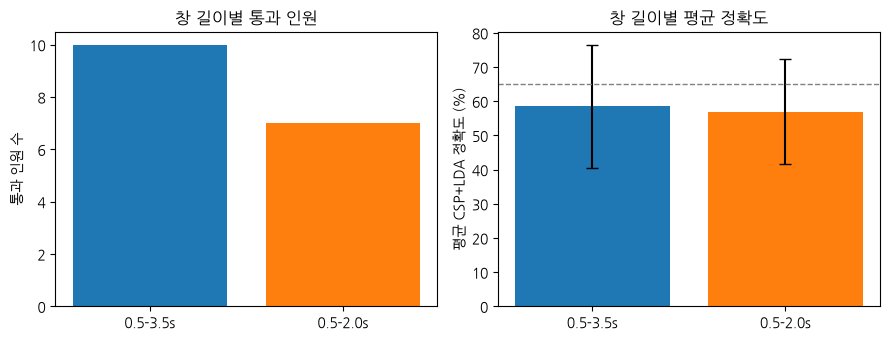

In [6]:
compare = gate_df.groupby(['window', 'window_label'], as_index=False).agg(
    n_passed=('passed', 'sum'),
    n_total=('passed', 'count'),
    mean_acc=('csp_lda_acc', 'mean'),
    std_acc=('csp_lda_acc', 'std'),
)
compare['mean_acc_pct'] = compare['mean_acc'] * 100
compare['std_acc_pct'] = compare['std_acc'] * 100

print(compare[['window_label', 'n_passed', 'n_total', 'mean_acc_pct', 'std_acc_pct']])

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9, 3.5))
ax0.bar(compare['window_label'], compare['n_passed'], color=['tab:blue', 'tab:orange'])
ax0.set_ylabel('통과 인원 수'); ax0.set_title('창 길이별 통과 인원')

ax1.bar(compare['window_label'], compare['mean_acc_pct'], yerr=compare['std_acc_pct'],
        capsize=4, color=['tab:blue', 'tab:orange'])
ax1.axhline(PASS_THRESHOLD * 100, color='gray', linestyle='--', linewidth=1)
ax1.set_ylabel('평균 CSP+LDA 정확도 (%)'); ax1.set_title('창 길이별 평균 정확도')

plt.tight_layout(); plt.show()


## 7. 창 길이 선택과 통과 피험자 저장

통과 인원이 더 많은 창 길이를 선택한다(동점이면 평균 정확도가 높은 쪽).

In [7]:
compare_sorted = compare.sort_values(['n_passed', 'mean_acc_pct'], ascending=False)
chosen = compare_sorted.iloc[0]
chosen_window_key = chosen['window']

print(f"선택된 창 길이: {chosen['window_label']} (통과 {int(chosen['n_passed'])}/{int(chosen['n_total'])}명, "
      f"평균 {chosen['mean_acc_pct']:.1f}%)")

selected_mask = (gate_df['window'] == chosen_window_key) & gate_df['passed']
selected_subjects = sorted(gate_df.loc[selected_mask, 'subject_id'].astype(int).tolist())

output = {
    'window_key': chosen_window_key,
    'window_label': chosen['window_label'],
    'npz_filename': WINDOW_FILES[chosen_window_key]['path'].split('/')[-1],
    'num_steps': WINDOW_FILES[chosen_window_key]['num_steps'],
    'pass_threshold': PASS_THRESHOLD,
    'n_selected': len(selected_subjects),
    'subjects': selected_subjects,
}

with open(OUT_JSON_PATH, 'w', encoding='utf-8') as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print('저장 완료:', OUT_JSON_PATH)
print(output)


선택된 창 길이: 0.5-3.5s (통과 10/40명, 평균 58.6%)
저장 완료: ../data/processed/selected_subjects.json
{'window_key': 'long', 'window_label': '0.5-3.5s', 'npz_filename': 'eeg_epochs_long.npz', 'num_steps': 384, 'pass_threshold': 0.65, 'n_selected': 10, 'subjects': [1, 2, 7, 10, 15, 25, 29, 31, 33, 34]}


## 정리

- mu(8–13 Hz) 대역통과 + CSP(학습셋에서만 적합)+LDA 5-fold CV로 피험자별 정확도를 구해 65% 이상인 피험자만 선별했다.
- 0.5–2.0s와 0.5–3.5s 두 창 길이를 비교해 통과 인원이 더 많은 쪽을 최종 선택했다.
- 선택된 창 길이와 통과 피험자 목록을 `selected_subjects.json`에 저장했다 (`window_key`, `npz_filename`, `num_steps`, `subjects` 포함).

다음 단계(04_train_compare)는 이 목록에 있는 피험자만, 선택된 창 길이의 데이터로 학습한다.